In [1]:
## Reference
# https://www.coursera.org/learn/introduction-computer-vision-watson-opencv

In [2]:
import copy
import os,sys
os.chdir('/Users/levgolod/Projects/car_classifier/')

In [18]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator


import pandas as pd
# import tensorflow.compat.v1 as tf

In [4]:
from common_params import parent_directory_images, parent_directory_url_csvs
import importlib
import sys,os
import pandas as pd
from timethis import timethis



In [5]:
from _02_preprocess_data.preprocess_data_fns import *

/Users/levgolod/Projects/venv3/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:

# module_path='../02_preprocess_data/preprocess_data_fns.py'
# spec = importlib.util.spec_from_file_location("preprocess_data_fns", module_path)
# preprocess_data_fns = importlib.util.module_from_spec(spec)
# sys.modules["preprocess_data_fns"] = preprocess_data_fns
# spec.loader.exec_module(preprocess_data_fns)
# preprocess_data_fns.process_image_files

In [11]:
IMAGE_SIZE = 256 # increase later
SAMPLE_SIZE = 10000 # increase later

class_names_use = ['sedan','suv','truck']
label_dict = {v:k for k,v in body_style_dict.items()}
print(label_dict)
class_names = list(label_dict.values())
class_labels_use = list([v for k,v in body_style_dict.items() if k in class_names_use])
class_labels_use

{0: 'sedan', 1: 'sportscar', 2: 'suv', 3: 'truck', 4: 'van', 5: 'wagon'}


[0, 2, 3]

{'sedan': 0, 'sportscar': 1, 'suv': 2, 'truck': 3, 'van': 4, 'wagon': 5}

### Ingest image data from disk

In [13]:
output_filename_train_val_holdout = f'{parent_directory_url_csvs}df_train_val_hold.csv'
df=pd.read_csv(output_filename_train_val_holdout).sample(frac=1)
df=df.loc[df['body_style'].isin(class_names_use), ].reset_index()
print(df.shape)
print(df.partition.value_counts(dropna=False,normalize=True))
df.head()

(7768, 10)
partition
train    0.718589
hold     0.147915
val      0.133496
Name: proportion, dtype: float64


,index,filepath,filename,filepath_to_use,vehicle_id,partition,make,model,body_style,body_style_index
0,129,/Users/levgolod/Projects/car_classifier/data/a...,7ef488cf788f4197bd605e2f9ca18722.jpg,/Users/levgolod/Projects/car_classifier/data/a...,730967984,train,bmw,3-series,sedan,0
1,3852,/Users/levgolod/Projects/car_classifier/data/a...,85dd8fe919674066a1e48bd93d9cf76e.jpg,/Users/levgolod/Projects/car_classifier/data/a...,731280630,train,ford,taurus,sedan,0
2,4522,/Users/levgolod/Projects/car_classifier/data/a...,f671365c36f94954b72c2eca2a851f78.jpg,/Users/levgolod/Projects/car_classifier/data/a...,733629508,val,honda,accord,sedan,0
3,7258,/Users/levgolod/Projects/car_classifier/data/a...,dbd9b933370b4b5382a2de2d2014daae.jpg,/Users/levgolod/Projects/car_classifier/data/a...,737315111,train,toyota,crown,sedan,0
4,1318,/Users/levgolod/Projects/car_classifier/data/a...,ac9ce603b3444557af58eaf77c43b336.jpg,/Users/levgolod/Projects/car_classifier/data/a...,737464986,train,bmw,x5,suv,2


torch.Size([256, 256])
d6b63c1cb72b4ec79d205eb94061b06d.jpg; true label suv


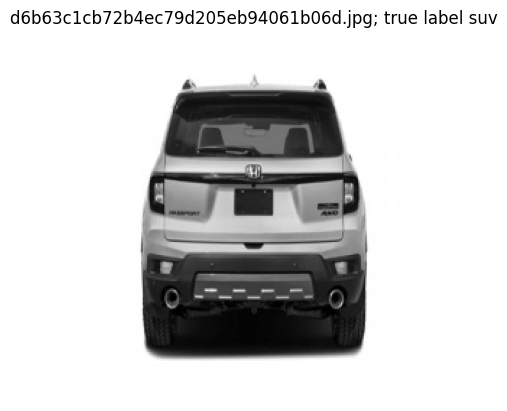

In [9]:
# data_sample = df.head()[['filepath_to_use','body_style_index']].values
# processed_images_sample = process_image_files(data_sample[:10], image_size=IMAGE_SIZE)
#
# i=2
# filename = os.path.basename(data_sample[i][0])
# image_array = processed_images_sample[i][0] #.squeeze()
# print(image_array.shape)
# label = label_dict.get( processed_images_sample[i][1])
# plt.imshow(image_array, cmap='gray')
# plt.axis("off")
# message=f"{filename}; true label {label}"
# print(message)
# plt.title(message)
# plt.show()

In [20]:
train_dataset = process_image_files(
    df.loc[df['partition']=='train', ['filepath_to_use','body_style_index']].head(SAMPLE_SIZE).values,
    image_size=IMAGE_SIZE,
)

test_dataset = process_image_files(
    df.loc[df['partition']=='val', ['filepath_to_use','body_style_index']].head(SAMPLE_SIZE).values,
    image_size=IMAGE_SIZE,
)

holdout_dataset = process_image_files(
    df.loc[df['partition']=='hold', ['filepath_to_use','body_style_index']].head(SAMPLE_SIZE).values,
    image_size=IMAGE_SIZE,
)

print(len(train_dataset),len(test_dataset),len(holdout_dataset))

5582 1037 1149


In [21]:
train_images, train_labels = \
    [x[0] for x in train_dataset], [x[1] for x in train_dataset]

test_images, test_labels = \
    [x[0] for x in test_dataset], [x[1] for x in test_dataset]

holdout_images, holdout_labels = \
    [x[0] for x in holdout_dataset], [x[1] for x in holdout_dataset]

## coerce to array - data
train_images = np.array([np.array(x) for x in train_images])
test_images = np.array([np.array(x) for x in test_images])
holdout_images = np.array([np.array(x) for x in holdout_images])

## coerce to array - labels
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)
holdout_labels = np.array(holdout_labels)

In [23]:
train_images.shape

(5582, 256, 256)

In [24]:
datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    zoom_range=[0.8, 1.0]
)

In [26]:
X_train, y_train = copy.deepcopy(train_images), copy.deepcopy(train_labels)


X_train = X_train.reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 1)
X_train.shape

(5582, 256, 256, 1)

In [29]:
augmented_images = []
augmented_labels = []

for i in range(len(X_train)):
    img = X_train[i].reshape((1, IMAGE_SIZE, IMAGE_SIZE, 1))  # Add batch dimension
    augmented = datagen.flow(img, batch_size=1)

    for _ in range(5):  # Generate 5 augmented images per original
        aug_img = next(augmented)[0]
        augmented_images.append(aug_img)
        augmented_labels.append(y_train[i])

# Convert back to NumPy arrays
X_aug = np.array(augmented_images)
y_aug = np.array(augmented_labels)


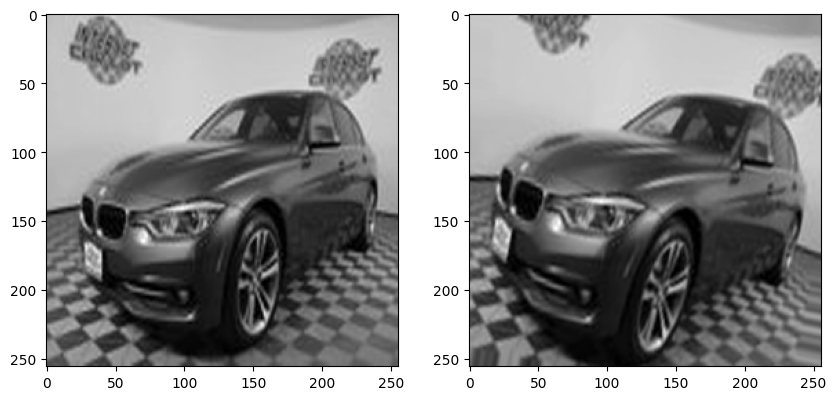

In [37]:
# show original image and then corresponding augmented image
i=0
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(np.squeeze(train_images[i]), cmap='gray')
plt.subplot(1,2,2)
plt.imshow(np.squeeze(augmented_images[int(i*5)+1]), cmap='gray')

In [30]:
len(X_aug), X_aug.shape

(27910, (27910, 256, 256, 1))

In [40]:
np.concatenate((X_train, X_train), axis=0).shape

(11164, 256, 256, 1)

In [45]:
## recombine and reshape the data

X_train =np.concatenate((X_train, X_aug), axis=0)
X_train = X_train.reshape(-1, IMAGE_SIZE, IMAGE_SIZE)

train_labels = np.concatenate((train_labels, y_aug), axis=0)


In [48]:
X_train.shape
train_labels.shape
train_images = X_train
train_images.shape, test_labels.shape

((33492, 256, 256), (1037,))

In [49]:
test_images.shape, test_labels.shape

((1037, 256, 256), (1037,))

In [16]:
# train_images = train_images/255.0
# test_images = test_images/255.0
# holdout_images = holdout_images/255.0

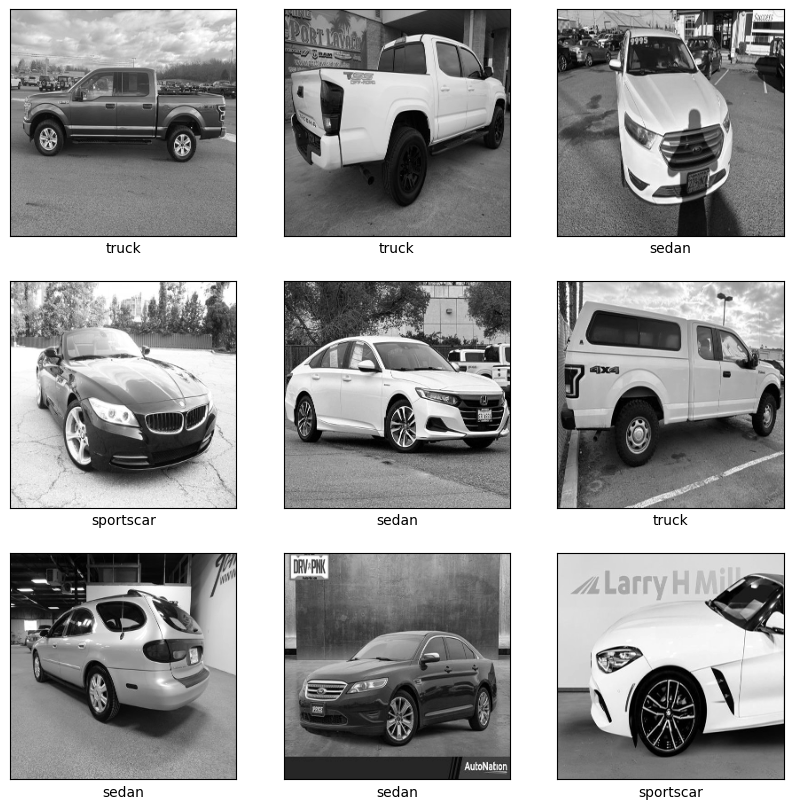

In [17]:
N=3
plt.figure(figsize=(10,10))
for i in range(N**2):
    plt.subplot(N,N,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(train_images[i]), cmap='gray')
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i]])

plt.show()

In [52]:

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1)))
model.add(layers.MaxPooling2D((2, 2)))
# model.add(layers.Conv2D(64, (3, 3), activation='relu'))
# model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(len(class_names))) #, activation='softmax'))

In [53]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# metrics=[
#         tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
#         tf.keras.metrics.Precision(name="precision"),
#         tf.keras.metrics.Recall(name="recall")
#     ]
# model.compile(optimizer='adam',
#               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#               metrics=metrics
#               )


history = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(test_images, test_labels))

Epoch 1/5
1047/1047 [==============================] - 670s 639ms/step - loss: 16.6319 - accuracy: 0.5490 - val_loss: 0.9849 - val_accuracy: 0.5593
Epoch 2/5
1047/1047 [==============================] - 688s 657ms/step - loss: 0.6238 - accuracy: 0.7440 - val_loss: 1.2681 - val_accuracy: 0.5902
Epoch 3/5
  40/1047 [>.............................] - ETA: 10:45 - loss: 0.2457 - accuracy: 0.9211

KeyboardInterrupt: 

In [ ]:
Epoch 1/5
1047/1047 [==============================] - 670s 639ms/step - loss: 16.6319 - accuracy: 0.5490 - val_loss: 0.9849 - val_accuracy: 0.5593
Epoch 2/5
1047/1047 [==============================] - 688s 657ms/step - loss: 0.6238 - accuracy: 0.7440 - val_loss: 1.2681 - val_accuracy: 0.5902

In [55]:

y_pred = np.argmax(model.predict(test_images), axis=1)
# y_true = np.argmax(y_val, axis=1)
_report = classification_report(test_labels, y_pred, target_names=class_names_use)
print(_report)

33/33 [==============================] - 4s 113ms/step
              precision    recall  f1-score   support

       sedan       0.71      0.70      0.71       499
         suv       0.49      0.26      0.34       210
       truck       0.51      0.67      0.58       328

    accuracy                           0.60      1037
   macro avg       0.57      0.54      0.54      1037
weighted avg       0.60      0.60      0.59      1037



In [31]:
pd.Series(test_labels).map(label_dict).value_counts()


sedan        499
truck        328
suv          210
sportscar     42
van           39
wagon         21
Name: count, dtype: int64

In [29]:
label_dict

{0: 'sedan', 1: 'sportscar', 2: 'suv', 3: 'truck', 4: 'van', 5: 'wagon'}